In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Electricity dataset
df_el = pd.read_csv('/content/household_power_consumption.txt', sep=';',
                    parse_dates={'datetime' : ['Date', 'Time']}, infer_datetime_format=True,
                    na_values=['nan','?'], low_memory=False)

df_el = df_el.set_index('datetime')
df_el = df_el[['Global_active_power']].astype('float32')
df_el = df_el.resample('H').mean()  # Resample hourly
df_el = df_el.fillna(method='ffill')

# Sunspot dataset
df_ss = pd.read_csv('/content/Sunspots.csv', parse_dates=['Date'], index_col='Date', infer_datetime_format=True)
df_ss = df_ss[['Monthly Mean Total Sunspot Number']].astype('float32')
df_ss = df_ss.fillna(method='ffill')

# Quick peek
print("Electricity Data Sample:")
print(df_el.head())
print("\nSunspot Data Sample:")
print(df_ss.head())


<ipython-input-1-3db5c23cd741>:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_el = pd.read_csv('/content/household_power_consumption.txt', sep=';',
<ipython-input-1-3db5c23cd741>:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_el = pd.read_csv('/content/household_power_consumption.txt', sep=';',
<ipython-input-1-3db5c23cd741>:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_el = pd.read_csv('/content/household_power_consumption.txt', sep=';',


Electricity Data Sample:
                     Global_active_power
datetime                                
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
2006-12-16 20:00:00             3.268567
2006-12-16 21:00:00             3.056467

Sunspot Data Sample:
            Monthly Mean Total Sunspot Number
Date                                         
1749-01-31                          96.699997
1749-02-28                         104.300003
1749-03-31                         116.699997
1749-04-30                          92.800003
1749-05-31                         141.699997


<ipython-input-1-3db5c23cd741>:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_el = df_el.resample('H').mean()  # Resample hourly
<ipython-input-1-3db5c23cd741>:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_el = df_el.fillna(method='ffill')
<ipython-input-1-3db5c23cd741>:18: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_ss = pd.read_csv('/content/Sunspots.csv', parse_dates=['Date'], index_col='Date', infer_datetime_format=True)
<ipython-input-1-3db5c23cd741>:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ss = df_ss

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Custom time series dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, index):
        x = self.data[index : index + self.seq_len]
        y = self.data[index + self.seq_len : index + self.seq_len + self.pred_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [3]:
def create_dataloaders(df, seq_len=96, pred_len=24, batch_size=64):
    train_size = int(len(df) * 0.7)
    val_size = int(len(df) * 0.15)
    test_size = len(df) - train_size - val_size

    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:]

    # Scale the data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    val_scaled = scaler.transform(val_data)
    test_scaled = scaler.transform(test_data)

    # Wrap into dataset
    train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len)
    val_dataset = TimeSeriesDataset(val_scaled, seq_len, pred_len)
    test_dataset = TimeSeriesDataset(test_scaled, seq_len, pred_len)

    # Create PyTorch DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, scaler


In [ ]:

seq_len = 180
pred_len = 1
batch_size = 32

# For electricity data
train_loader_el, val_loader_el, test_loader_el, scaler_el = create_dataloaders(df_el, seq_len, pred_len, batch_size)

# For sunspot data
train_loader_ss, val_loader_ss, test_loader_ss, scaler_ss = create_dataloaders(df_ss, seq_len, pred_len, batch_size)


In [5]:
import torch.nn as nn

class LSTMTimeSeries(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMTimeSeries, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Pass through LSTM
        lstm_out, _ = self.lstm(x)
        # Take only the last output
        out = self.fc(lstm_out[:, -1, :])
        return out


In [47]:
!pip install optuna --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 21.9 MB/s eta 0:00:00


In [ ]:
import optuna
import torch.optim as optim

def objective_single_dataset(trial, train_loader, val_loader, input_size=1, output_size=1):
   
    hidden_size = trial.suggest_int('hidden_size', 16, 128)
    num_layers = trial.suggest_int('num_layers', 1, 50)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)  

    # Create model
    model = LSTMTimeSeries(input_size, hidden_size, num_layers, output_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train for a few epochs to evaluate
    model.train()
    for epoch in range(10):  
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader)

    return val_loss


In [ ]:
study_ss = optuna.create_study(direction='minimize')
study_ss.optimize(lambda trial: objective_single_dataset(trial, train_loader_ss, val_loader_ss), n_trials=20)
print("Best Sunspot Model Params:", study_ss.best_params)


[I 2025-04-21 01:05:17,835] A new study created in memory with name: no-name-9e05ff45-8589-4192-a226-1815322df993
[I 2025-04-21 01:05:37,919] Trial 0 finished with value: 0.05147438319399953 and parameters: {'hidden_size': 18, 'num_layers': 14, 'lr': 0.0005543028773341505}. Best is trial 0 with value: 0.05147438319399953.
[I 2025-04-21 01:05:43,398] Trial 1 finished with value: 0.004141073010396212 and parameters: {'hidden_size': 110, 'num_layers': 4, 'lr': 0.004195208842504226}. Best is trial 1 with value: 0.004141073010396212.
[I 2025-04-21 01:06:03,914] Trial 2 finished with value: 0.048327615344896914 and parameters: {'hidden_size': 112, 'num_layers': 15, 'lr': 0.003861008635143329}. Best is trial 1 with value: 0.004141073010396212.
[I 2025-04-21 01:06:32,479] Trial 3 finished with value: 0.050587193574756384 and parameters: {'hidden_size': 73, 'num_layers': 40, 'lr': 0.000844806084510888}. Best is trial 1 with value: 0.004141073010396212.
[I 2025-04-21 01:06:38,546] Trial 4 finish

Best Sunspot Model Params: {'hidden_size': 110, 'num_layers': 4, 'lr': 0.004195208842504226}


In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=5, model_name='best_model.pth'):
    import time
    start_time = time.time()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch.squeeze(-1))
                val_loss += loss.item()
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_name)
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print("Early stopping triggered.")
                model.load_state_dict(torch.load(model_name))
                break

    end_time = time.time()
    print(f"Total training time: {end_time - start_time:.2f} seconds")

    return model, train_losses, val_losses


In [10]:
# Best hyperparameters found earlier for Sunspot model
best_params_ss = {'hidden_size': 92, 'num_layers': 6, 'lr': 0.0019005368816324164}

# Define LSTM model for Electricity dataset
model_el = LSTMTimeSeries(
    input_size=1,
    hidden_size=best_params_ss['hidden_size'],
    num_layers=best_params_ss['num_layers'],
    output_size=1
)

# Define optimizer and loss function
optimizer_el = torch.optim.Adam(model_el.parameters(), lr=best_params_ss['lr'])
criterion = nn.MSELoss()

# Train the model with time tracking and automatic saving of best weights
model_el, train_losses_el, val_losses_el = train_model(
    model_el,
    train_loader_el,
    val_loader_el,
    criterion,
    optimizer_el,
    epochs=50,
    model_name="lstm_model_el.pth"  # Save best model with this name
)


Epoch 1/50, Train Loss: 0.0369, Val Loss: 0.0338
Epoch 2/50, Train Loss: 0.0351, Val Loss: 0.0388
Epoch 3/50, Train Loss: 0.0343, Val Loss: 0.0357
Epoch 4/50, Train Loss: 0.0284, Val Loss: 0.0157
Epoch 5/50, Train Loss: 0.0157, Val Loss: 0.0142
Epoch 6/50, Train Loss: 0.0152, Val Loss: 0.0140
Epoch 7/50, Train Loss: 0.0148, Val Loss: 0.0142
Epoch 8/50, Train Loss: 0.0142, Val Loss: 0.0154
Epoch 9/50, Train Loss: 0.0140, Val Loss: 0.0134
Epoch 10/50, Train Loss: 0.0141, Val Loss: 0.0136
Epoch 11/50, Train Loss: 0.0145, Val Loss: 0.0129
Epoch 12/50, Train Loss: 0.0134, Val Loss: 0.0141
Epoch 13/50, Train Loss: 0.0130, Val Loss: 0.0129
Epoch 14/50, Train Loss: 0.0136, Val Loss: 0.0136
Epoch 15/50, Train Loss: 0.0134, Val Loss: 0.0140
Epoch 16/50, Train Loss: 0.0131, Val Loss: 0.0150
Epoch 17/50, Train Loss: 0.0128, Val Loss: 0.0143
Epoch 18/50, Train Loss: 0.0139, Val Loss: 0.0148
Early stopping triggered.
Total training time: 9.46 seconds


In [13]:
# Best hyperparameters (previously found)
best_params_ss = {'hidden_size': 92, 'num_layers': 6, 'lr': 0.0019005368816324164}

# Define the LSTM model for Sunspot dataset
model_ss = LSTMTimeSeries(
    input_size=1,
    hidden_size=best_params_ss['hidden_size'],
    num_layers=best_params_ss['num_layers'],
    output_size=1
)

# Define optimizer and loss
optimizer_ss = torch.optim.Adam(model_ss.parameters(), lr=best_params_ss['lr'])
criterion = nn.MSELoss()

# Train the model with logging and saving best weights
model_ss, train_losses_ss, val_losses_ss = train_model(
    model_ss,
    train_loader_ss,
    val_loader_ss,
    criterion,
    optimizer_ss,
    epochs=50,
    model_name="lstm_model_ss.pth"
)


Epoch 1/50, Train Loss: 0.0213, Val Loss: 0.0109
Epoch 2/50, Train Loss: 0.0067, Val Loss: 0.0063
Epoch 3/50, Train Loss: 0.0058, Val Loss: 0.0061
Epoch 4/50, Train Loss: 0.0051, Val Loss: 0.0066
Epoch 5/50, Train Loss: 0.0047, Val Loss: 0.0065
Epoch 6/50, Train Loss: 0.0043, Val Loss: 0.0048
Epoch 7/50, Train Loss: 0.0041, Val Loss: 0.0051
Epoch 8/50, Train Loss: 0.0048, Val Loss: 0.0066
Epoch 9/50, Train Loss: 0.0045, Val Loss: 0.0059
Epoch 10/50, Train Loss: 0.0043, Val Loss: 0.0044
Epoch 11/50, Train Loss: 0.0042, Val Loss: 0.0042
Epoch 12/50, Train Loss: 0.0046, Val Loss: 0.0075
Epoch 13/50, Train Loss: 0.0043, Val Loss: 0.0048
Epoch 14/50, Train Loss: 0.0040, Val Loss: 0.0047
Epoch 15/50, Train Loss: 0.0046, Val Loss: 0.0046
Epoch 16/50, Train Loss: 0.0041, Val Loss: 0.0040
Epoch 17/50, Train Loss: 0.0043, Val Loss: 0.0061
Epoch 18/50, Train Loss: 0.0040, Val Loss: 0.0040
Epoch 19/50, Train Loss: 0.0040, Val Loss: 0.0044
Epoch 20/50, Train Loss: 0.0040, Val Loss: 0.0072
Epoch 21/

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def test_model_scaled(model, test_loader, criterion, name="Dataset"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch).cpu().numpy()
            targets = y_batch.cpu().numpy()

            all_preds.extend(outputs.flatten())
            all_targets.extend(targets.flatten())

    mae = mean_absolute_error(all_targets, all_preds)
    mse = mean_squared_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)

    print(f"{name} — Scaled Evaluation:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")

    return all_preds, all_targets, mae, mse, r2


In [53]:
preds_el, targets_el, mae_el, mse_el, r2_el = test_model_scaled(
    model_el, test_loader_el, criterion, name="Electricity Dataset"
)


Electricity Dataset — Scaled Evaluation:
MAE: 0.0659
MSE: 0.0083
R²: 0.3874


In [54]:
preds_ss_scaled, targets_ss_scaled, mae_ss_scaled, mse_ss_scaled, r2_ss_scaled = test_model_scaled(
    model_ss, test_loader_ss, criterion, name="Sunspot Dataset"
)


Sunspot Dataset — Scaled Evaluation:
MAE: 0.0393
MSE: 0.0029
R²: 0.8566


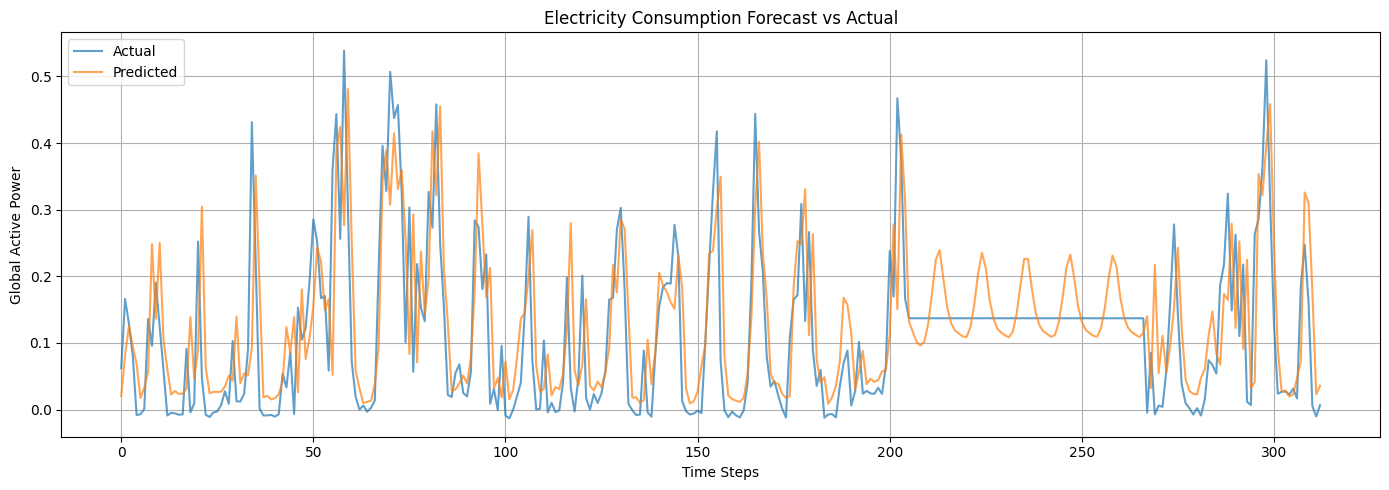

In [55]:
plt.figure(figsize=(14, 5))
plt.plot(targets_el, label='Actual', alpha=0.7)
plt.plot(preds_el, label='Predicted', alpha=0.7)
plt.title("Electricity Consumption Forecast vs Actual")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


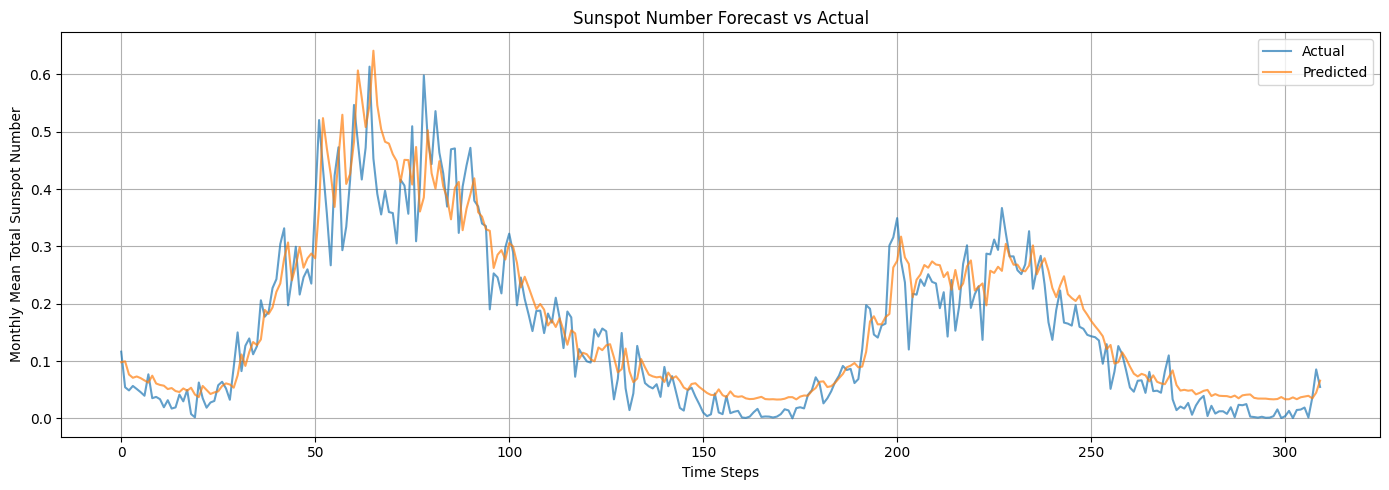

In [56]:
plt.figure(figsize=(14, 5))
plt.plot(targets_ss_scaled, label='Actual', alpha=0.7) # Use targets_ss_scaled
plt.plot(preds_ss_scaled, label='Predicted', alpha=0.7) # Use preds_ss_scaled
plt.title("Sunspot Number Forecast vs Actual")
plt.xlabel("Time Steps")
plt.ylabel("Monthly Mean Total Sunspot Number")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Train vs Validation Loss Curve (per model)

In [57]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=5, model_name='best_model.pth'):
    import time
    start_time = time.time()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch.squeeze(-1))
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_name)
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print("Early stopping triggered.")
                model.load_state_dict(torch.load(model_name))
                break

    end_time = time.time()
    print(f"Total training time: {end_time - start_time:.2f} seconds")

    return model, train_losses, val_losses


In [66]:
model_ss, train_losses_ss, val_losses_ss = train_model(
    model_ss,
    train_loader_ss,
    val_loader_ss,
    criterion,
    optimizer_ss,
    epochs=50,
    model_name="lstm_model_ss.pth"
)


Epoch 1/50, Train Loss: 0.0037, Val Loss: 0.0067
Epoch 2/50, Train Loss: 0.0037, Val Loss: 0.0052
Epoch 3/50, Train Loss: 0.0038, Val Loss: 0.0064
Epoch 4/50, Train Loss: 0.0039, Val Loss: 0.0050
Epoch 5/50, Train Loss: 0.0036, Val Loss: 0.0058
Epoch 6/50, Train Loss: 0.0040, Val Loss: 0.0056
Epoch 7/50, Train Loss: 0.0041, Val Loss: 0.0058
Epoch 8/50, Train Loss: 0.0041, Val Loss: 0.0045
Epoch 9/50, Train Loss: 0.0037, Val Loss: 0.0049
Epoch 10/50, Train Loss: 0.0036, Val Loss: 0.0052
Epoch 11/50, Train Loss: 0.0038, Val Loss: 0.0045
Epoch 12/50, Train Loss: 0.0035, Val Loss: 0.0060
Epoch 13/50, Train Loss: 0.0037, Val Loss: 0.0054
Early stopping triggered.
Total training time: 7.49 seconds


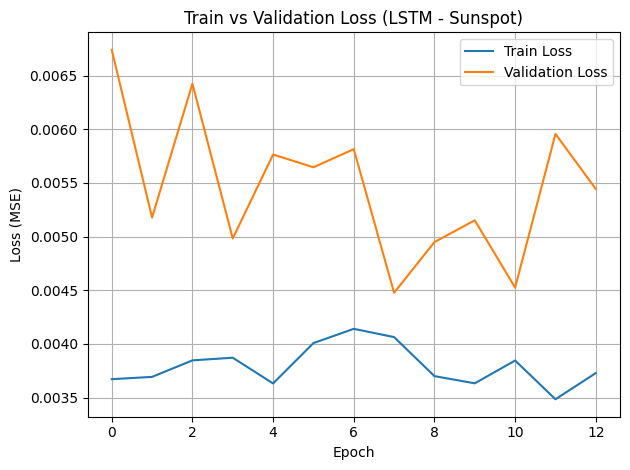

In [67]:
plt.plot(train_losses_ss, label='Train Loss')
plt.plot(val_losses_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (LSTM - Sunspot)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


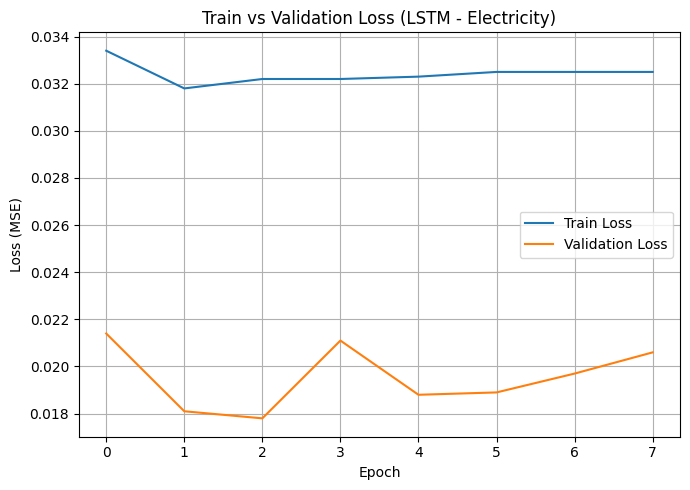

In [69]:
plt.figure(figsize=(7, 5))
plt.plot(train_losses_el, label='Train Loss')
plt.plot(val_losses_el, label='Validation Loss')
plt.title('Train vs Validation Loss (LSTM - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#GRU

In [ ]:
import torch.nn as nn

class GRUTimeSeries(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(GRUTimeSeries, self).__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])  
        return out


In [ ]:
import optuna
import torch.optim as optim

def gru_objective(trial, train_loader, val_loader, input_size=1, output_size=1):
    hidden_size = trial.suggest_int("hidden_size", 16, 128)
    num_layers = trial.suggest_int("num_layers", 1, 50)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = GRUTimeSeries(input_size, hidden_size, num_layers, output_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(10):  # Light tuning
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()

    val_loss /= len(val_loader)
    return val_loss


In [ ]:
study_gru_ss = optuna.create_study(direction="minimize")
study_gru_ss.optimize(lambda trial: gru_objective(trial, train_loader_ss, val_loader_ss), n_trials=30)

# Display the best hyperparameters
print("📌 Best GRU parameters for Sunspot:")
print(study_gru_ss.best_params)


[I 2025-04-21 01:15:10,077] A new study created in memory with name: no-name-988a1510-8dba-46a8-9d77-e2b29159568a
[I 2025-04-21 01:15:34,226] Trial 0 finished with value: 0.04618787383660674 and parameters: {'hidden_size': 91, 'num_layers': 31, 'lr': 0.00031672005926371513}. Best is trial 0 with value: 0.04618787383660674.
[I 2025-04-21 01:15:44,830] Trial 1 finished with value: 0.005192884325515479 and parameters: {'hidden_size': 112, 'num_layers': 11, 'lr': 0.0017492934733997873}. Best is trial 1 with value: 0.005192884325515479.
[I 2025-04-21 01:15:49,796] Trial 2 finished with value: 0.00521282140398398 and parameters: {'hidden_size': 74, 'num_layers': 8, 'lr': 0.00258279905433652}. Best is trial 1 with value: 0.005192884325515479.
[I 2025-04-21 01:16:28,489] Trial 3 finished with value: 0.04722498571500182 and parameters: {'hidden_size': 95, 'num_layers': 49, 'lr': 0.00012750614246294565}. Best is trial 1 with value: 0.005192884325515479.
[I 2025-04-21 01:17:14,912] Trial 4 finish

📌 Best GRU parameters for Sunspot:
{'hidden_size': 23, 'num_layers': 1, 'lr': 0.004891128585032528}


In [ ]:
from torch.utils.data import ConcatDataset, DataLoader


full_train_ds_ss = ConcatDataset([train_loader_ss.dataset, val_loader_ss.dataset])
full_train_loader_ss = DataLoader(full_train_ds_ss, batch_size=32, shuffle=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


best_gru_ss = GRUTimeSeries(
    input_size=1,
    hidden_size=23,
    num_layers=1,
    output_size=1
).to(device)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(best_gru_ss.parameters(), lr=0.004891128585032528)


best_gru_ss, train_losses_gru_ss, val_losses_gru_ss = train_model(
    best_gru_ss,
    full_train_loader_ss,
    val_loader_ss,
    criterion,
    optimizer,
    epochs=50,
    model_name="gru_model_ss.pth"
)


Epoch 1/50, Train Loss: 0.0156, Val Loss: 0.0045
Epoch 2/50, Train Loss: 0.0044, Val Loss: 0.0044
Epoch 3/50, Train Loss: 0.0042, Val Loss: 0.0044
Epoch 4/50, Train Loss: 0.0043, Val Loss: 0.0041
Epoch 5/50, Train Loss: 0.0042, Val Loss: 0.0041
Epoch 6/50, Train Loss: 0.0042, Val Loss: 0.0039
Epoch 7/50, Train Loss: 0.0040, Val Loss: 0.0037
Epoch 8/50, Train Loss: 0.0042, Val Loss: 0.0038
Epoch 9/50, Train Loss: 0.0041, Val Loss: 0.0050
Epoch 10/50, Train Loss: 0.0039, Val Loss: 0.0037
Epoch 11/50, Train Loss: 0.0040, Val Loss: 0.0039
Epoch 12/50, Train Loss: 0.0040, Val Loss: 0.0038
Epoch 13/50, Train Loss: 0.0040, Val Loss: 0.0039
Epoch 14/50, Train Loss: 0.0039, Val Loss: 0.0039
Epoch 15/50, Train Loss: 0.0039, Val Loss: 0.0043
Early stopping triggered.
Total training time: 4.18 seconds


In [ ]:
for epoch in range(50):
    best_gru_ss.train()
    train_loss = 0.0
    for x_batch, y_batch in full_train_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = best_gru_ss(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(full_train_loader_ss)
    train_losses_gru_ss.append(train_loss)

    # Validation on val_loader_ss
    best_gru_ss.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = best_gru_ss(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
        val_loss /= len(val_loader_ss)
        val_losses_gru_ss.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch 1/50 — Train Loss: 0.0221, Val Loss: 0.0049
Epoch 2/50 — Train Loss: 0.0043, Val Loss: 0.0042
Epoch 3/50 — Train Loss: 0.0043, Val Loss: 0.0041
Epoch 4/50 — Train Loss: 0.0041, Val Loss: 0.0043
Epoch 5/50 — Train Loss: 0.0041, Val Loss: 0.0040
Epoch 6/50 — Train Loss: 0.0041, Val Loss: 0.0042
Epoch 7/50 — Train Loss: 0.0041, Val Loss: 0.0040
Epoch 8/50 — Train Loss: 0.0041, Val Loss: 0.0045
Epoch 9/50 — Train Loss: 0.0040, Val Loss: 0.0038
Epoch 10/50 — Train Loss: 0.0039, Val Loss: 0.0039
Epoch 11/50 — Train Loss: 0.0041, Val Loss: 0.0039
Epoch 12/50 — Train Loss: 0.0040, Val Loss: 0.0041
Epoch 13/50 — Train Loss: 0.0040, Val Loss: 0.0036
Epoch 14/50 — Train Loss: 0.0040, Val Loss: 0.0037
Epoch 15/50 — Train Loss: 0.0040, Val Loss: 0.0039
Epoch 16/50 — Train Loss: 0.0039, Val Loss: 0.0036
Epoch 17/50 — Train Loss: 0.0039, Val Loss: 0.0039
Epoch 18/50 — Train Loss: 0.0038, Val Loss: 0.0039
Epoch 19/50 — Train Loss: 0.0040, Val Loss: 0.0038
Epoch 20/50 — Train Loss: 0.0039, Val Lo

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_gru_ss.eval()
preds_ss = []
targets_ss = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = best_gru_ss(x_batch)
        preds_ss.extend(output.cpu().numpy().flatten())
        targets_ss.extend(y_batch.cpu().numpy().flatten())

mae_ss = mean_absolute_error(targets_ss, preds_ss)
mse_ss = mean_squared_error(targets_ss, preds_ss)
r2_ss = r2_score(targets_ss, preds_ss)

print("📊 Final GRU Evaluation — Sunspot Test Set (Scaled):")
print(f"MAE: {mae_ss:.4f}")
print(f"MSE: {mse_ss:.4f}")
print(f"R²: {r2_ss:.4f}")


📊 Final GRU Evaluation — Sunspot Test Set (Scaled):
MAE: 0.0352
MSE: 0.0023
R²: 0.8862


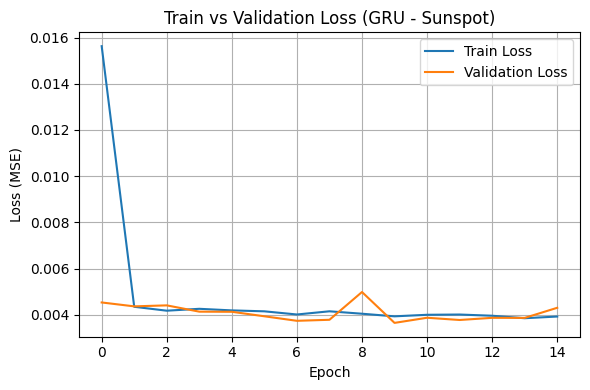

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses_gru_ss, label='Train Loss')
plt.plot(val_losses_gru_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (GRU - Sunspot)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Initialize GRU model with Sunspot-tuned best parameters
best_gru_el = GRUTimeSeries(
    input_size=1,
    hidden_size=23,       # From best GRU hyperparams (Sunspot tuning)
    num_layers=1,
    output_size=1
).to(device)

# Optimizer and loss function
optimizer_el = torch.optim.Adam(best_gru_el.parameters(), lr=0.004891128585032528)
criterion = nn.MSELoss()

# Train the GRU model on Electricity dataset
best_gru_el, train_losses_gru_el, val_losses_gru_el = train_model(
    best_gru_el,
    train_loader_el,
    val_loader_el,
    criterion,
    optimizer_el,
    epochs=50,
    model_name="gru_model_el.pth"  
)


Epoch 1/50, Train Loss: 0.0321, Val Loss: 0.0169
Epoch 2/50, Train Loss: 0.0157, Val Loss: 0.0148
Epoch 3/50, Train Loss: 0.0146, Val Loss: 0.0159
Epoch 4/50, Train Loss: 0.0145, Val Loss: 0.0149
Epoch 5/50, Train Loss: 0.0146, Val Loss: 0.0154
Epoch 6/50, Train Loss: 0.0147, Val Loss: 0.0150
Epoch 7/50, Train Loss: 0.0148, Val Loss: 0.0147
Epoch 8/50, Train Loss: 0.0148, Val Loss: 0.0161
Epoch 9/50, Train Loss: 0.0147, Val Loss: 0.0147
Epoch 10/50, Train Loss: 0.0144, Val Loss: 0.0147
Epoch 11/50, Train Loss: 0.0144, Val Loss: 0.0147
Epoch 12/50, Train Loss: 0.0148, Val Loss: 0.0148
Epoch 13/50, Train Loss: 0.0144, Val Loss: 0.0154
Epoch 14/50, Train Loss: 0.0143, Val Loss: 0.0144
Epoch 15/50, Train Loss: 0.0138, Val Loss: 0.0140
Epoch 16/50, Train Loss: 0.0139, Val Loss: 0.0142
Epoch 17/50, Train Loss: 0.0136, Val Loss: 0.0133
Epoch 18/50, Train Loss: 0.0135, Val Loss: 0.0139
Epoch 19/50, Train Loss: 0.0133, Val Loss: 0.0142
Epoch 20/50, Train Loss: 0.0137, Val Loss: 0.0135
Epoch 21/

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_gru_el.eval()
preds_el = []
targets_el = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = best_gru_el(x_batch)
        preds_el.extend(output.cpu().numpy().flatten())
        targets_el.extend(y_batch.cpu().numpy().flatten())

mae_el = mean_absolute_error(targets_el, preds_el)
mse_el = mean_squared_error(targets_el, preds_el)
r2_el = r2_score(targets_el, preds_el)

print("📊 Final GRU Evaluation — Electricity Test Set (Scaled):")
print(f"MAE: {mae_el:.4f}")
print(f"MSE: {mse_el:.4f}")
print(f"R²: {r2_el:.4f}")


📊 Final GRU Evaluation — Electricity Test Set (Scaled):
MAE: 0.0593
MSE: 0.0071
R²: 0.4739


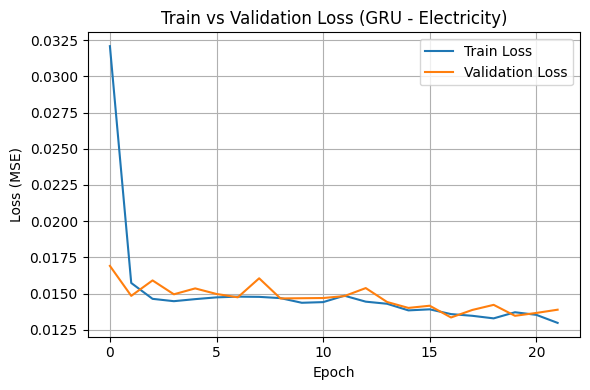

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses_gru_el, label='Train Loss')
plt.plot(val_losses_gru_el, label='Validation Loss')
plt.title('Train vs Validation Loss (GRU - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#1D CNN

In [ ]:
import torch.nn as nn

class CNN1DTimeSeries(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, output_size):
        super(CNN1DTimeSeries, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size,
                               out_channels=num_filters,
                               kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveAvgPool1d(1)  
        self.fc = nn.Linear(num_filters, output_size)

    def forward(self, x):
        # x shape: [batch_size, seq_len, input_size] → permute to [batch, input, seq_len]
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.fc(x)
        return x


In [ ]:
import optuna
import torch.optim as optim

def cnn1d_objective(trial, train_loader, val_loader, input_size=1, output_size=1):
    # Hyperparameters
    num_filters = trial.suggest_int("num_filters", 16, 128)
    kernel_size = trial.suggest_int("kernel_size", 2, 10)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = CNN1DTimeSeries(input_size, num_filters, kernel_size, output_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Lightweight training
    model.train()
    for epoch in range(10):
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    return val_loss / len(val_loader)


In [ ]:
# Run tuning for Sunspot
study_cnn_ss = optuna.create_study(direction="minimize")
study_cnn_ss.optimize(lambda trial: cnn1d_objective(trial, train_loader_ss, val_loader_ss), n_trials=20)

# Output the best params
print("✅ Best 1D CNN parameters for Sunspot:")
print(study_cnn_ss.best_params)


[I 2025-04-21 01:40:57,086] A new study created in memory with name: no-name-47500731-37e0-4b03-aebc-7b3ecec76cb8
[I 2025-04-21 01:40:58,542] Trial 0 finished with value: 0.05005738567560911 and parameters: {'num_filters': 66, 'kernel_size': 5, 'lr': 0.006879963078545349}. Best is trial 0 with value: 0.05005738567560911.
[I 2025-04-21 01:40:59,941] Trial 1 finished with value: 0.0427406357601285 and parameters: {'num_filters': 110, 'kernel_size': 8, 'lr': 0.0001752169711869233}. Best is trial 1 with value: 0.0427406357601285.
[I 2025-04-21 01:41:01,699] Trial 2 finished with value: 0.042977814003825186 and parameters: {'num_filters': 55, 'kernel_size': 2, 'lr': 0.0013435437414339006}. Best is trial 1 with value: 0.0427406357601285.
[I 2025-04-21 01:41:03,278] Trial 3 finished with value: 0.04324453701265156 and parameters: {'num_filters': 91, 'kernel_size': 4, 'lr': 0.0026680692494335614}. Best is trial 1 with value: 0.0427406357601285.
[I 2025-04-21 01:41:04,717] Trial 4 finished with

✅ Best 1D CNN parameters for Sunspot:
{'num_filters': 19, 'kernel_size': 9, 'lr': 0.0023221601721152645}


In [76]:
import torch
import torch.nn as nn
from torch.utils.data import ConcatDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# 1D CNN model
class CNN1DTimeSeries(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, output_size):
        super(CNN1DTimeSeries, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=num_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(num_filters, output_size)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.global_pool(x).squeeze(-1)
        return self.fc(x)

# Best Optuna-tuned parameters for CNN on Sunspot
best_cnn_params = {'num_filters': 19, 'kernel_size': 9, 'lr': 0.0023221601721152645}

# Dataloaders
full_train_ds_ss = ConcatDataset([train_loader_ss.dataset, val_loader_ss.dataset])
full_train_loader_ss = DataLoader(full_train_ds_ss, batch_size=32, shuffle=True)

# Initialize model, loss, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model_ss = CNN1DTimeSeries(1, best_cnn_params['num_filters'], best_cnn_params['kernel_size'], 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn_model_ss.parameters(), lr=best_cnn_params['lr'])

# Training with early stopping + save best model
train_losses_cnn_ss = []
val_losses_cnn_ss = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    cnn_model_ss.train()
    train_loss = 0.0
    for x_batch, y_batch in full_train_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn_model_ss(x_batch), y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(full_train_loader_ss)
    train_losses_cnn_ss.append(train_loss)

    # Validation
    cnn_model_ss.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss = criterion(cnn_model_ss(x_batch), y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_ss)
    val_losses_cnn_ss.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(cnn_model_ss.state_dict(), "cnn_model_ss.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            cnn_model_ss.load_state_dict(torch.load("cnn_model_ss.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")

# Evaluation on test set
cnn_model_ss.eval()
preds_ss = []
targets_ss = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds_ss.extend(cnn_model_ss(x_batch).cpu().numpy().flatten())
        targets_ss.extend(y_batch.cpu().numpy().flatten())

mae_ss = mean_absolute_error(targets_ss, preds_ss)
mse_ss = mean_squared_error(targets_ss, preds_ss)
r2_ss = r2_score(targets_ss, preds_ss)

print("\n📊 Final CNN Evaluation — Sunspot Test Set (Scaled):")
print(f"MAE: {mae_ss:.4f}")
print(f"MSE: {mse_ss:.4f}")
print(f"R²: {r2_ss:.4f}")


Epoch 1/50 — Train Loss: 0.0277, Val Loss: 0.0448
Epoch 2/50 — Train Loss: 0.0264, Val Loss: 0.0426
Epoch 3/50 — Train Loss: 0.0263, Val Loss: 0.0460
Epoch 4/50 — Train Loss: 0.0257, Val Loss: 0.0429
Epoch 5/50 — Train Loss: 0.0257, Val Loss: 0.0416
Epoch 6/50 — Train Loss: 0.0255, Val Loss: 0.0418
Epoch 7/50 — Train Loss: 0.0253, Val Loss: 0.0407
Epoch 8/50 — Train Loss: 0.0249, Val Loss: 0.0414
Epoch 9/50 — Train Loss: 0.0247, Val Loss: 0.0394
Epoch 10/50 — Train Loss: 0.0243, Val Loss: 0.0386
Epoch 11/50 — Train Loss: 0.0236, Val Loss: 0.0387
Epoch 12/50 — Train Loss: 0.0231, Val Loss: 0.0368
Epoch 13/50 — Train Loss: 0.0226, Val Loss: 0.0351
Epoch 14/50 — Train Loss: 0.0217, Val Loss: 0.0352
Epoch 15/50 — Train Loss: 0.0215, Val Loss: 0.0333
Epoch 16/50 — Train Loss: 0.0207, Val Loss: 0.0314
Epoch 17/50 — Train Loss: 0.0205, Val Loss: 0.0299
Epoch 18/50 — Train Loss: 0.0194, Val Loss: 0.0288
Epoch 19/50 — Train Loss: 0.0191, Val Loss: 0.0291
Epoch 20/50 — Train Loss: 0.0181, Val Lo

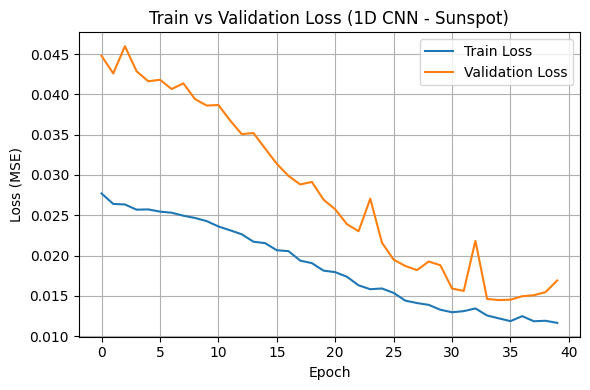

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses_cnn_ss, label='Train Loss')
plt.plot(val_losses_cnn_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (1D CNN - Sunspot)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [78]:
import torch.nn as nn

class CNN1DModel(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, output_size):
        super(CNN1DModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=num_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(num_filters, output_size)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, C=1, T]
        x = self.conv1(x)
        x = self.relu(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x


In [79]:
import time

# Initialize model with Sunspot-tuned best parameters
cnn_el = CNN1DModel(input_size=1, num_filters=19, kernel_size=9, output_size=1).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn_el.parameters(), lr=0.0023221601721152645)

# Training with time tracking and early stopping
train_losses_cnn_el = []
val_losses_cnn_el = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    cnn_el.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = cnn_el(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_el)
    train_losses_cnn_el.append(train_loss)

    # Validation
    cnn_el.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = cnn_el(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_el)
    val_losses_cnn_el.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(cnn_el.state_dict(), "cnn_model_el.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            cnn_el.load_state_dict(torch.load("cnn_model_el.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0515, Val Loss: 0.0295
Epoch 2/50 — Train Loss: 0.0341, Val Loss: 0.0300
Epoch 3/50 — Train Loss: 0.0339, Val Loss: 0.0294
Epoch 4/50 — Train Loss: 0.0337, Val Loss: 0.0299
Epoch 5/50 — Train Loss: 0.0336, Val Loss: 0.0280
Epoch 6/50 — Train Loss: 0.0334, Val Loss: 0.0276
Epoch 7/50 — Train Loss: 0.0337, Val Loss: 0.0279
Epoch 8/50 — Train Loss: 0.0336, Val Loss: 0.0279
Epoch 9/50 — Train Loss: 0.0334, Val Loss: 0.0285
Epoch 10/50 — Train Loss: 0.0339, Val Loss: 0.0288
Epoch 11/50 — Train Loss: 0.0344, Val Loss: 0.0294
Early stopping triggered.
Total training time: 1.74 seconds


In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

cnn_el.eval()
preds_el = []
targets_el = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = cnn_el(x_batch)
        preds_el.extend(output.cpu().numpy().flatten())
        targets_el.extend(y_batch.cpu().numpy().flatten())

mae_el = mean_absolute_error(targets_el, preds_el)
mse_el = mean_squared_error(targets_el, preds_el)
r2_el = r2_score(targets_el, preds_el)

print("📊 Final CNN Evaluation — Electricity Test Set (Scaled):")
print(f"MAE: {mae_el:.4f}")
print(f"MSE: {mse_el:.4f}")
print(f"R²: {r2_el:.4f}")


📊 Final CNN Evaluation — Electricity Test Set (Scaled):
MAE: 0.0908
MSE: 0.0139
R²: -0.0298


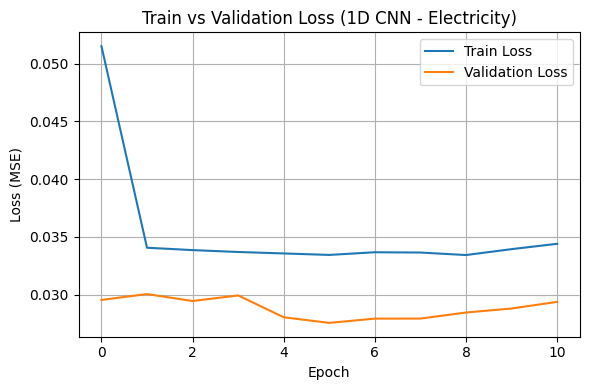

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses_cnn_el, label='Train Loss')
plt.plot(val_losses_cnn_el, label='Validation Loss')
plt.title('Train vs Validation Loss (1D CNN - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#LSTM+CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from sklearn.metrics import mean_squared_error

# CNN + LSTM Hybrid Model
class CNN_LSTM(nn.Module):
    def __init__(self, input_size, cnn_filters, kernel_size, lstm_hidden, lstm_layers, output_size):
        super(CNN_LSTM, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=cnn_filters, kernel_size=kernel_size)
        self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, output_size)

    def forward(self, x):
        # Input shape: (batch_size, seq_len, input_size) → transpose for CNN
        x = x.transpose(1, 2)  # (batch, input_size, seq_len)
        x = self.conv1(x)      # (batch, filters, new_seq_len)
        x = x.transpose(1, 2)  # (batch, new_seq_len, filters)
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])  # Take last time step
        return out

#  Objective function for Optuna
def cnn_lstm_objective(trial):
    cnn_filters = trial.suggest_int("cnn_filters", 16, 128)
    kernel_size = trial.suggest_int("kernel_size", 2, 10)
    lstm_hidden = trial.suggest_int("lstm_hidden", 16, 128)
    lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = CNN_LSTM(
        input_size=1,
        cnn_filters=cnn_filters,
        kernel_size=kernel_size,
        lstm_hidden=lstm_hidden,
        lstm_layers=lstm_layers,
        output_size=1
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(10):  # Short run for tuning
        for x_batch, y_batch in train_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch).cpu().numpy()
            val_preds.extend(output.flatten())
            val_targets.extend(y_batch.cpu().numpy().flatten())

    return mean_squared_error(val_targets, val_preds)

#  Run Optuna Tuning
study_cnn_lstm_ss = optuna.create_study(direction="minimize")
study_cnn_lstm_ss.optimize(cnn_lstm_objective, n_trials=30)

#  Best parameters
print("Best CNN + LSTM params — Sunspot:")
print(study_cnn_lstm_ss.best_params)


[I 2025-04-21 02:02:29,396] A new study created in memory with name: no-name-3f818ad8-1a9b-4fc1-921a-4afa1f6228b5
[I 2025-04-21 02:02:34,965] Trial 0 finished with value: 0.0042311360749111675 and parameters: {'cnn_filters': 104, 'kernel_size': 7, 'lstm_hidden': 123, 'lstm_layers': 3, 'lr': 0.008347997454597458}. Best is trial 0 with value: 0.0042311360749111675.
[I 2025-04-21 02:02:38,163] Trial 1 finished with value: 0.005029563139074294 and parameters: {'cnn_filters': 80, 'kernel_size': 3, 'lstm_hidden': 23, 'lstm_layers': 3, 'lr': 0.006788127798841446}. Best is trial 0 with value: 0.0042311360749111675.
[I 2025-04-21 02:02:40,624] Trial 2 finished with value: 0.004388229648787267 and parameters: {'cnn_filters': 51, 'kernel_size': 9, 'lstm_hidden': 67, 'lstm_layers': 2, 'lr': 0.0007681668115710323}. Best is trial 0 with value: 0.0042311360749111675.
[I 2025-04-21 02:02:42,781] Trial 3 finished with value: 0.004038419125745595 and parameters: {'cnn_filters': 96, 'kernel_size': 4, 'ls

Best CNN + LSTM params — Sunspot:
{'cnn_filters': 117, 'kernel_size': 6, 'lstm_hidden': 96, 'lstm_layers': 1, 'lr': 0.00018264030562729412}


In [82]:
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, input_size, cnn_filters, kernel_size, lstm_hidden, lstm_layers, output_size):
        super(CNN_LSTM, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=cnn_filters, kernel_size=kernel_size)
        self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, output_size)

    def forward(self, x):
        # Input shape: (batch_size, seq_len, input_size)
        x = x.transpose(1, 2)  # (batch, input_size, seq_len)
        x = self.conv1(x)      # (batch, cnn_filters, new_seq_len)
        x = x.transpose(1, 2)  # (batch, new_seq_len, cnn_filters)
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])  # Use the last time step
        return out


In [ ]:
import time
from torch.utils.data import ConcatDataset, DataLoader


full_train_ds_ss = ConcatDataset([train_loader_ss.dataset, val_loader_ss.dataset])
full_train_loader_ss = DataLoader(full_train_ds_ss, batch_size=32, shuffle=True)

# Build model with best parameters
best_cnn_lstm_ss = CNN_LSTM(
    input_size=1,
    cnn_filters=117,
    kernel_size=6,
    lstm_hidden=96,
    lstm_layers=1,
    output_size=1
).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(best_cnn_lstm_ss.parameters(), lr=0.00018264030562729412)

# Tracking & early stopping
train_losses_cnn_lstm_ss = []
val_losses_cnn_lstm_ss = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

# Training loop
for epoch in range(50):
    best_cnn_lstm_ss.train()
    train_loss = 0.0
    for x_batch, y_batch in full_train_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = best_cnn_lstm_ss(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(full_train_loader_ss)
    train_losses_cnn_lstm_ss.append(train_loss)

    # Validation loss
    best_cnn_lstm_ss.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = best_cnn_lstm_ss(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_ss)
    val_losses_cnn_lstm_ss.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Save best model + early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(best_cnn_lstm_ss.state_dict(), "cnn_lstm_model_ss.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            best_cnn_lstm_ss.load_state_dict(torch.load("cnn_lstm_model_ss.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0154, Val Loss: 0.0074
Epoch 2/50 — Train Loss: 0.0054, Val Loss: 0.0060
Epoch 3/50 — Train Loss: 0.0050, Val Loss: 0.0056
Epoch 4/50 — Train Loss: 0.0048, Val Loss: 0.0050
Epoch 5/50 — Train Loss: 0.0046, Val Loss: 0.0044
Epoch 6/50 — Train Loss: 0.0044, Val Loss: 0.0043
Epoch 7/50 — Train Loss: 0.0042, Val Loss: 0.0041
Epoch 8/50 — Train Loss: 0.0041, Val Loss: 0.0040
Epoch 9/50 — Train Loss: 0.0040, Val Loss: 0.0040
Epoch 10/50 — Train Loss: 0.0040, Val Loss: 0.0039
Epoch 11/50 — Train Loss: 0.0039, Val Loss: 0.0043
Epoch 12/50 — Train Loss: 0.0039, Val Loss: 0.0044
Epoch 13/50 — Train Loss: 0.0039, Val Loss: 0.0041
Epoch 14/50 — Train Loss: 0.0039, Val Loss: 0.0040
Epoch 15/50 — Train Loss: 0.0039, Val Loss: 0.0037
Epoch 16/50 — Train Loss: 0.0038, Val Loss: 0.0038
Epoch 17/50 — Train Loss: 0.0038, Val Loss: 0.0039
Epoch 18/50 — Train Loss: 0.0038, Val Loss: 0.0037
Epoch 19/50 — Train Loss: 0.0039, Val Loss: 0.0037
Epoch 20/50 — Train Loss: 0.0038, Val Lo

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_cnn_lstm_ss.eval()
preds_ss = []
targets_ss = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = best_cnn_lstm_ss(x_batch)
        preds_ss.extend(output.cpu().numpy().flatten())
        targets_ss.extend(y_batch.cpu().numpy().flatten())

mae_ss = mean_absolute_error(targets_ss, preds_ss)
mse_ss = mean_squared_error(targets_ss, preds_ss)
r2_ss = r2_score(targets_ss, preds_ss)

print("📊 Final CNN + LSTM Evaluation — Sunspot Test Set (Scaled):")
print(f"MAE: {mae_ss:.4f}")
print(f"MSE: {mse_ss:.4f}")
print(f"R²: {r2_ss:.4f}")


📊 Final CNN + LSTM Evaluation — Sunspot Test Set (Scaled):
MAE: 0.0347
MSE: 0.0023
R²: 0.8882


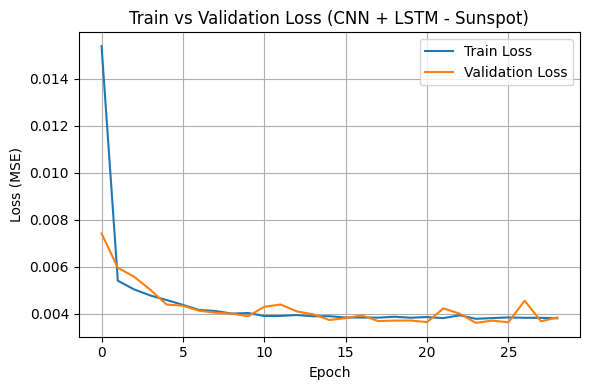

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses_cnn_lstm_ss, label='Train Loss')
plt.plot(val_losses_cnn_lstm_ss, label='Validation Loss')
plt.title('Train vs Validation Loss (CNN + LSTM - Sunspot)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [86]:
import torch.nn as nn

class CNNLSTMModel(nn.Module):
    def __init__(self, input_size, cnn_filters, kernel_size, lstm_hidden, lstm_layers, output_size):
        super(CNNLSTMModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=cnn_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        x = x.permute(0, 2, 1)  # CNN expects (batch, input_channels, seq_len)
        x = self.conv1(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1)  # Back to (batch, seq_len, channels) for LSTM
        x, _ = self.lstm(x)
        out = self.fc(x[:, -1, :])  # Output from last LSTM timestep
        return out


In [87]:
import time

# Re-initialize model with best parameters
cnn_lstm_el = CNNLSTMModel(
    input_size=1,
    cnn_filters=117,
    kernel_size=6,
    lstm_hidden=96,
    lstm_layers=1,
    output_size=1
).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn_lstm_el.parameters(), lr=0.00018264030562729412)

# Training loop with early stopping and timing
train_losses_cnn_lstm_el = []
val_losses_cnn_lstm_el = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    cnn_lstm_el.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = cnn_lstm_el(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_el)
    train_losses_cnn_lstm_el.append(train_loss)

    # Validation
    cnn_lstm_el.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = cnn_lstm_el(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_el)
    val_losses_cnn_lstm_el.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(cnn_lstm_el.state_dict(), "cnn_lstm_model_el.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            cnn_lstm_el.load_state_dict(torch.load("cnn_lstm_model_el.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0352, Val Loss: 0.0255
Epoch 2/50 — Train Loss: 0.0251, Val Loss: 0.0201
Epoch 3/50 — Train Loss: 0.0205, Val Loss: 0.0191
Epoch 4/50 — Train Loss: 0.0182, Val Loss: 0.0173
Epoch 5/50 — Train Loss: 0.0161, Val Loss: 0.0157
Epoch 6/50 — Train Loss: 0.0154, Val Loss: 0.0150
Epoch 7/50 — Train Loss: 0.0149, Val Loss: 0.0144
Epoch 8/50 — Train Loss: 0.0145, Val Loss: 0.0141
Epoch 9/50 — Train Loss: 0.0140, Val Loss: 0.0139
Epoch 10/50 — Train Loss: 0.0140, Val Loss: 0.0139
Epoch 11/50 — Train Loss: 0.0136, Val Loss: 0.0140
Epoch 12/50 — Train Loss: 0.0138, Val Loss: 0.0137
Epoch 13/50 — Train Loss: 0.0136, Val Loss: 0.0144
Epoch 14/50 — Train Loss: 0.0134, Val Loss: 0.0140
Epoch 15/50 — Train Loss: 0.0139, Val Loss: 0.0137
Epoch 16/50 — Train Loss: 0.0138, Val Loss: 0.0142
Epoch 17/50 — Train Loss: 0.0134, Val Loss: 0.0136
Epoch 18/50 — Train Loss: 0.0134, Val Loss: 0.0137
Epoch 19/50 — Train Loss: 0.0134, Val Loss: 0.0135
Epoch 20/50 — Train Loss: 0.0131, Val Lo

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

cnn_lstm_el.eval()
preds_el = []
targets_el = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = cnn_lstm_el(x_batch)
        preds_el.extend(output.cpu().numpy().flatten())
        targets_el.extend(y_batch.cpu().numpy().flatten())

# Compute metrics (already scaled, no inverse transform)
mae_el = mean_absolute_error(targets_el, preds_el)
mse_el = mean_squared_error(targets_el, preds_el)
r2_el = r2_score(targets_el, preds_el)

print("📊 CNN + LSTM (Sunspot Params) on Electricity — Test Set (Scaled):")
print(f"MAE: {mae_el:.4f}")
print(f"MSE: {mse_el:.4f}")
print(f"R²: {r2_el:.4f}")


📊 CNN + LSTM (Sunspot Params) on Electricity — Test Set (Scaled):
MAE: 0.0652
MSE: 0.0079
R²: 0.4107


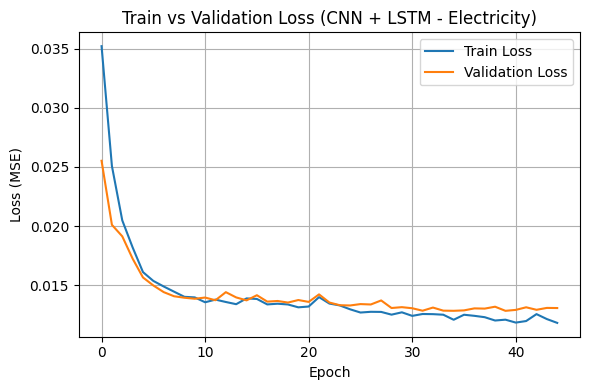

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses_cnn_lstm_el, label='Train Loss')
plt.plot(val_losses_cnn_lstm_el, label='Validation Loss')
plt.title('Train vs Validation Loss (CNN + LSTM - Electricity)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


from here, based on recommendation from professor, we retrained and tuned best hyper params on electricity dataset as well and checked on both 

In [48]:
import optuna


In [49]:
import torch.nn as nn
import torch.optim as optim

def objective_single_dataset(trial, train_loader, val_loader, input_size=1, output_size=1):
    hidden_size = trial.suggest_int('hidden_size', 16, 128)
    num_layers = trial.suggest_int('num_layers', 1, 50)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = LSTMTimeSeries(input_size, hidden_size, num_layers, output_size)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(10):  # lightweight tuning
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    return val_loss / len(val_loader)


In [50]:
study_lstm_el = optuna.create_study(direction="minimize")
study_lstm_el.optimize(
    lambda trial: objective_single_dataset(trial, train_loader_el, val_loader_el),
    n_trials=20
)

print("✅ Best LSTM parameters tuned on Electricity:")
print(study_lstm_el.best_params)


[I 2025-04-23 20:45:54,014] A new study created in memory with name: no-name-4ba7d888-038e-4a76-be59-3d6e5a276f91
[I 2025-04-23 20:46:05,167] Trial 0 finished with value: 0.029793976247310637 and parameters: {'hidden_size': 100, 'num_layers': 7, 'lr': 0.0012844920980982152}. Best is trial 0 with value: 0.029793976247310637.
[I 2025-04-23 20:46:15,117] Trial 1 finished with value: 0.01715778037905693 and parameters: {'hidden_size': 109, 'num_layers': 6, 'lr': 0.0023391673236757738}. Best is trial 1 with value: 0.01715778037905693.
[I 2025-04-23 20:46:32,197] Trial 2 finished with value: 0.02950513083487749 and parameters: {'hidden_size': 81, 'num_layers': 20, 'lr': 0.00808666735214178}. Best is trial 1 with value: 0.01715778037905693.
[I 2025-04-23 20:47:06,062] Trial 3 finished with value: 0.02839159034192562 and parameters: {'hidden_size': 104, 'num_layers': 23, 'lr': 0.00042166477549410755}. Best is trial 1 with value: 0.01715778037905693.
[I 2025-04-23 20:48:22,966] Trial 4 finished

✅ Best LSTM parameters tuned on Electricity:
{'hidden_size': 49, 'num_layers': 2, 'lr': 0.003832152666897919}


In [90]:
import time
import torch.nn as nn
import torch.optim as optim

# Define the model with Optuna-tuned params
model_lstm_el = LSTMTimeSeries(
    input_size=1,
    hidden_size=49,
    num_layers=2,
    output_size=1
).to(device)

# Optimizer & loss
criterion = nn.MSELoss()
optimizer = optim.Adam(model_lstm_el.parameters(), lr=0.003832152666897919)

# Tracking and early stopping
train_losses_lstm_el = []
val_losses_lstm_el = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

# Training loop
for epoch in range(50):
    model_lstm_el.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_lstm_el(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_el)
    train_losses_lstm_el.append(train_loss)

    # Validation
    model_lstm_el.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_lstm_el(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_el)
    val_losses_lstm_el.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_lstm_el.state_dict(), "lstm_model_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            model_lstm_el.load_state_dict(torch.load("lstm_model_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0316, Val Loss: 0.0179
Epoch 2/50 — Train Loss: 0.0165, Val Loss: 0.0153
Epoch 3/50 — Train Loss: 0.0148, Val Loss: 0.0147
Epoch 4/50 — Train Loss: 0.0143, Val Loss: 0.0161
Epoch 5/50 — Train Loss: 0.0149, Val Loss: 0.0151
Epoch 6/50 — Train Loss: 0.0143, Val Loss: 0.0135
Epoch 7/50 — Train Loss: 0.0143, Val Loss: 0.0164
Epoch 8/50 — Train Loss: 0.0143, Val Loss: 0.0155
Epoch 9/50 — Train Loss: 0.0141, Val Loss: 0.0143
Epoch 10/50 — Train Loss: 0.0139, Val Loss: 0.0133
Epoch 11/50 — Train Loss: 0.0131, Val Loss: 0.0130
Epoch 12/50 — Train Loss: 0.0132, Val Loss: 0.0159
Epoch 13/50 — Train Loss: 0.0130, Val Loss: 0.0131
Epoch 14/50 — Train Loss: 0.0132, Val Loss: 0.0130
Epoch 15/50 — Train Loss: 0.0133, Val Loss: 0.0136
Epoch 16/50 — Train Loss: 0.0131, Val Loss: 0.0133
Epoch 17/50 — Train Loss: 0.0138, Val Loss: 0.0129
Epoch 18/50 — Train Loss: 0.0126, Val Loss: 0.0134
Epoch 19/50 — Train Loss: 0.0129, Val Loss: 0.0130
Epoch 20/50 — Train Loss: 0.0129, Val Lo

In [91]:
# Rebuild model for SS using el-tuned params
model_lstm_ss = LSTMTimeSeries(
    input_size=1,
    hidden_size=49,
    num_layers=2,
    output_size=1
).to(device)

# Optimizer & loss
optimizer = optim.Adam(model_lstm_ss.parameters(), lr=0.003832152666897919)
criterion = nn.MSELoss()

# Training with early stopping
train_losses_lstm_ss = []
val_losses_lstm_ss = []
best_val_loss = float('inf')
epochs_no_improve = 0
start_time = time.time()

for epoch in range(50):
    model_lstm_ss.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_lstm_ss(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_ss)
    train_losses_lstm_ss.append(train_loss)

    # Validation
    model_lstm_ss.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_lstm_ss(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_ss)
    val_losses_lstm_ss.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_lstm_ss.state_dict(), "lstm_model_ss_from_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == 5:
            print("Early stopping triggered.")
            model_lstm_ss.load_state_dict(torch.load("lstm_model_ss_from_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0152, Val Loss: 0.0055
Epoch 2/50 — Train Loss: 0.0053, Val Loss: 0.0048
Epoch 3/50 — Train Loss: 0.0046, Val Loss: 0.0048
Epoch 4/50 — Train Loss: 0.0045, Val Loss: 0.0064
Epoch 5/50 — Train Loss: 0.0042, Val Loss: 0.0046
Epoch 6/50 — Train Loss: 0.0042, Val Loss: 0.0052
Epoch 7/50 — Train Loss: 0.0042, Val Loss: 0.0057
Epoch 8/50 — Train Loss: 0.0042, Val Loss: 0.0045
Epoch 9/50 — Train Loss: 0.0040, Val Loss: 0.0044
Epoch 10/50 — Train Loss: 0.0041, Val Loss: 0.0052
Epoch 11/50 — Train Loss: 0.0042, Val Loss: 0.0046
Epoch 12/50 — Train Loss: 0.0040, Val Loss: 0.0063
Epoch 13/50 — Train Loss: 0.0041, Val Loss: 0.0039
Epoch 14/50 — Train Loss: 0.0041, Val Loss: 0.0040
Epoch 15/50 — Train Loss: 0.0041, Val Loss: 0.0041
Epoch 16/50 — Train Loss: 0.0042, Val Loss: 0.0044
Epoch 17/50 — Train Loss: 0.0040, Val Loss: 0.0060
Epoch 18/50 — Train Loss: 0.0041, Val Loss: 0.0049
Early stopping triggered.
Total training time: 4.82 seconds


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_lstm_el.eval()
preds_el = []
targets_el = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_lstm_el(x_batch)
        preds_el.extend(output.cpu().numpy().flatten())
        targets_el.extend(y_batch.cpu().numpy().flatten())

mae_el = mean_absolute_error(targets_el, preds_el)
mse_el = mean_squared_error(targets_el, preds_el)
r2_el = r2_score(targets_el, preds_el)

print("📊 Evaluation of LSTM (Optuna-tuned on Electricity) — Electricity Test Set:")
print(f"MAE: {mae_el:.4f}")
print(f"MSE: {mse_el:.4f}")
print(f"R²: {r2_el:.4f}")


📊 Evaluation of LSTM (Optuna-tuned on Electricity) — Electricity Test Set:
MAE: 0.0625
MSE: 0.0076
R²: 0.4391


In [93]:
model_lstm_ss.eval()
preds_ss = []
targets_ss = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_lstm_ss(x_batch)
        preds_ss.extend(output.cpu().numpy().flatten())
        targets_ss.extend(y_batch.cpu().numpy().flatten())

mae_ss = mean_absolute_error(targets_ss, preds_ss)
mse_ss = mean_squared_error(targets_ss, preds_ss)
r2_ss = r2_score(targets_ss, preds_ss)

print("📊 Evaluation of LSTM (Optuna-tuned on Electricity) — Sunspot Test Set:")
print(f"MAE: {mae_ss:.4f}")
print(f"MSE: {mse_ss:.4f}")
print(f"R²: {r2_ss:.4f}")


📊 Evaluation of LSTM (Optuna-tuned on Electricity) — Sunspot Test Set:
MAE: 0.0324
MSE: 0.0023
R²: 0.8901


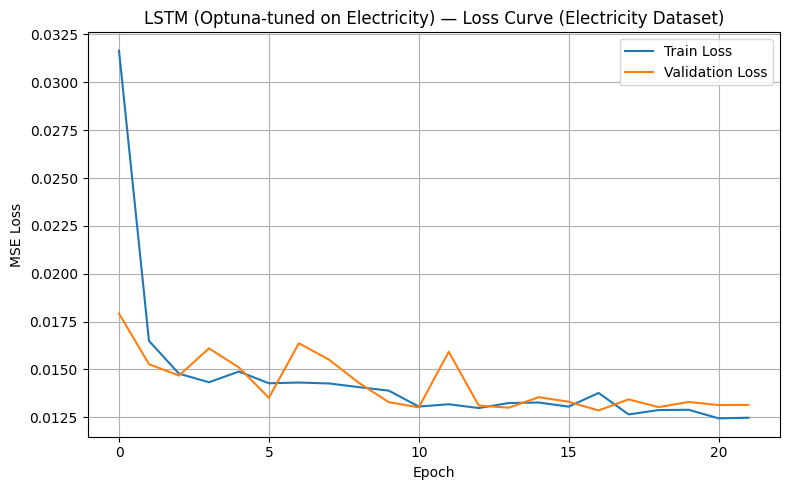

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses_lstm_el, label='Train Loss')
plt.plot(val_losses_lstm_el, label='Validation Loss')
plt.title('LSTM (Optuna-tuned on Electricity) — Loss Curve (Electricity Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


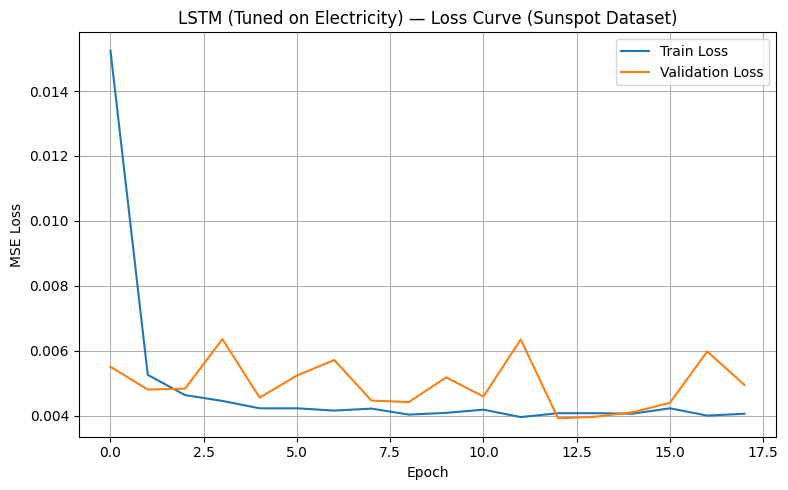

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_lstm_ss, label='Train Loss')
plt.plot(val_losses_lstm_ss, label='Validation Loss')
plt.title('LSTM (Tuned on Electricity) — Loss Curve (Sunspot Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


GRU

In [ ]:
import optuna
import torch.nn as nn
import torch.optim as optim



def objective_gru_el(trial):
    hidden_size = trial.suggest_int("hidden_size", 16, 128)
    num_layers = trial.suggest_int("num_layers", 1, 50)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = GRUTimeSeries(input_size=1, hidden_size=hidden_size, num_layers=num_layers, output_size=1).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Lightweight tuning (10 epochs)
    model.train()
    for epoch in range(10):
        for x_batch, y_batch in train_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()

    return val_loss / len(val_loader_el)


In [97]:
study_gru_el = optuna.create_study(direction="minimize")
study_gru_el.optimize(objective_gru_el, n_trials=20)

# Output the best params
print("✅ Best GRU parameters tuned on Electricity:")
print(study_gru_el.best_params)


[I 2025-04-23 21:03:20,402] A new study created in memory with name: no-name-b740068a-19ef-4ea5-a4e5-cd9643966911
[I 2025-04-23 21:03:38,802] Trial 0 finished with value: 0.033103211969137195 and parameters: {'hidden_size': 79, 'num_layers': 25, 'lr': 0.002293859764848775}. Best is trial 0 with value: 0.033103211969137195.
[I 2025-04-23 21:03:51,782] Trial 1 finished with value: 0.03141194712370634 and parameters: {'hidden_size': 40, 'num_layers': 32, 'lr': 0.001092932755339923}. Best is trial 1 with value: 0.03141194712370634.
[I 2025-04-23 21:04:02,273] Trial 2 finished with value: 0.03121586740016937 and parameters: {'hidden_size': 111, 'num_layers': 10, 'lr': 0.006542356149242983}. Best is trial 2 with value: 0.03121586740016937.
[I 2025-04-23 21:04:17,934] Trial 3 finished with value: 0.0328585522249341 and parameters: {'hidden_size': 84, 'num_layers': 22, 'lr': 0.0012076662996431359}. Best is trial 2 with value: 0.03121586740016937.
[I 2025-04-23 21:04:54,326] Trial 4 finished wi

✅ Best GRU parameters tuned on Electricity:
{'hidden_size': 63, 'num_layers': 8, 'lr': 0.000697345386864869}


In [98]:
import time

model_gru_el = GRUTimeSeries(
    input_size=1,
    hidden_size=63,
    num_layers=8,
    output_size=1
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_gru_el.parameters(), lr=0.000697345386864869)

train_losses_gru_el = []
val_losses_gru_el = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    model_gru_el.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_gru_el(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_el)
    train_losses_gru_el.append(train_loss)

    model_gru_el.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_gru_el(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_el)
    val_losses_gru_el.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_gru_el.state_dict(), "gru_model_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            model_gru_el.load_state_dict(torch.load("gru_model_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0348, Val Loss: 0.0312
Epoch 2/50 — Train Loss: 0.0334, Val Loss: 0.0268
Epoch 3/50 — Train Loss: 0.0332, Val Loss: 0.0292
Epoch 4/50 — Train Loss: 0.0326, Val Loss: 0.0230
Epoch 5/50 — Train Loss: 0.0170, Val Loss: 0.0153
Epoch 6/50 — Train Loss: 0.0147, Val Loss: 0.0138
Epoch 7/50 — Train Loss: 0.0144, Val Loss: 0.0142
Epoch 8/50 — Train Loss: 0.0150, Val Loss: 0.0170
Epoch 9/50 — Train Loss: 0.0141, Val Loss: 0.0135
Epoch 10/50 — Train Loss: 0.0141, Val Loss: 0.0150
Epoch 11/50 — Train Loss: 0.0139, Val Loss: 0.0143
Epoch 12/50 — Train Loss: 0.0143, Val Loss: 0.0138
Epoch 13/50 — Train Loss: 0.0137, Val Loss: 0.0135
Epoch 14/50 — Train Loss: 0.0136, Val Loss: 0.0145
Epoch 15/50 — Train Loss: 0.0135, Val Loss: 0.0133
Epoch 16/50 — Train Loss: 0.0134, Val Loss: 0.0135
Epoch 17/50 — Train Loss: 0.0138, Val Loss: 0.0135
Epoch 18/50 — Train Loss: 0.0133, Val Loss: 0.0136
Epoch 19/50 — Train Loss: 0.0135, Val Loss: 0.0132
Epoch 20/50 — Train Loss: 0.0133, Val Lo

In [99]:
model_gru_ss = GRUTimeSeries(
    input_size=1,
    hidden_size=63,
    num_layers=8,
    output_size=1
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_gru_ss.parameters(), lr=0.000697345386864869)

train_losses_gru_ss = []
val_losses_gru_ss = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    model_gru_ss.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_gru_ss(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_ss)
    train_losses_gru_ss.append(train_loss)

    model_gru_ss.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_gru_ss(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_ss)
    val_losses_gru_ss.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_gru_ss.state_dict(), "gru_model_ss_from_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            model_gru_ss.load_state_dict(torch.load("gru_model_ss_from_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0234, Val Loss: 0.0146
Epoch 2/50 — Train Loss: 0.0068, Val Loss: 0.0066
Epoch 3/50 — Train Loss: 0.0060, Val Loss: 0.0081
Epoch 4/50 — Train Loss: 0.0053, Val Loss: 0.0056
Epoch 5/50 — Train Loss: 0.0050, Val Loss: 0.0050
Epoch 6/50 — Train Loss: 0.0047, Val Loss: 0.0047
Epoch 7/50 — Train Loss: 0.0043, Val Loss: 0.0053
Epoch 8/50 — Train Loss: 0.0044, Val Loss: 0.0042
Epoch 9/50 — Train Loss: 0.0042, Val Loss: 0.0046
Epoch 10/50 — Train Loss: 0.0041, Val Loss: 0.0041
Epoch 11/50 — Train Loss: 0.0041, Val Loss: 0.0066
Epoch 12/50 — Train Loss: 0.0040, Val Loss: 0.0043
Epoch 13/50 — Train Loss: 0.0041, Val Loss: 0.0044
Epoch 14/50 — Train Loss: 0.0042, Val Loss: 0.0045
Epoch 15/50 — Train Loss: 0.0040, Val Loss: 0.0046
Early stopping triggered.
Total training time: 11.05 seconds


In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_gru_el.eval()
preds_el = []
targets_el = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_gru_el(x_batch)
        preds_el.extend(output.cpu().numpy().flatten())
        targets_el.extend(y_batch.cpu().numpy().flatten())

mae_el = mean_absolute_error(targets_el, preds_el)
mse_el = mean_squared_error(targets_el, preds_el)
r2_el = r2_score(targets_el, preds_el)

print("📊 GRU (Optuna-tuned on Electricity) — Electricity Test Set:")
print(f"MAE: {mae_el:.4f}")
print(f"MSE: {mse_el:.4f}")
print(f"R²: {r2_el:.4f}")


📊 GRU (Optuna-tuned on Electricity) — Electricity Test Set:
MAE: 0.0600
MSE: 0.0078
R²: 0.4240


In [101]:
model_gru_ss.eval()
preds_ss = []
targets_ss = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_gru_ss(x_batch)
        preds_ss.extend(output.cpu().numpy().flatten())
        targets_ss.extend(y_batch.cpu().numpy().flatten())

mae_ss = mean_absolute_error(targets_ss, preds_ss)
mse_ss = mean_squared_error(targets_ss, preds_ss)
r2_ss = r2_score(targets_ss, preds_ss)

print("📊 GRU (Optuna-tuned on Electricity) — Sunspot Test Set:")
print(f"MAE: {mae_ss:.4f}")
print(f"MSE: {mse_ss:.4f}")
print(f"R²: {r2_ss:.4f}")


📊 GRU (Optuna-tuned on Electricity) — Sunspot Test Set:
MAE: 0.0344
MSE: 0.0026
R²: 0.8744


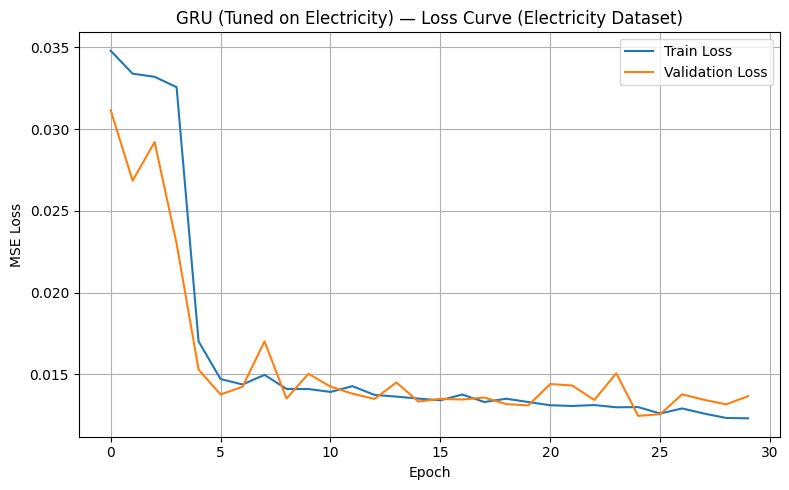

In [103]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_gru_el, label='Train Loss')
plt.plot(val_losses_gru_el, label='Validation Loss')
plt.title('GRU (Tuned on Electricity) — Loss Curve (Electricity Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


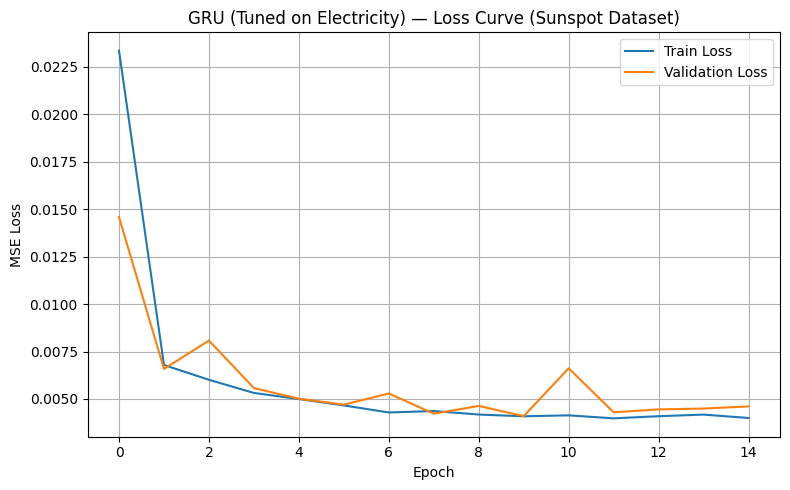

In [104]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_gru_ss, label='Train Loss')
plt.plot(val_losses_gru_ss, label='Validation Loss')
plt.title('GRU (Tuned on Electricity) — Loss Curve (Sunspot Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1d cnn

In [ ]:
import optuna
import torch.nn as nn
import torch.optim as optim



def objective_cnn1d_el(trial):
    num_filters = trial.suggest_int("num_filters", 16, 128)
    kernel_size = trial.suggest_int("kernel_size", 2, 10)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = CNN1DTimeSeries(input_size=1, num_filters=num_filters, kernel_size=kernel_size, output_size=1).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(10):  # light tuning
        for x_batch, y_batch in train_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()

    return val_loss / len(val_loader_el)


In [106]:
study_cnn1d_el = optuna.create_study(direction="minimize")
study_cnn1d_el.optimize(objective_cnn1d_el, n_trials=20)

# Output best parameters
print("✅ Best 1D CNN parameters tuned on Electricity:")
print(study_cnn1d_el.best_params)


[I 2025-04-23 21:17:41,266] A new study created in memory with name: no-name-779fe61c-f64e-44fd-a17b-60077307017c
[I 2025-04-23 21:17:43,927] Trial 0 finished with value: 0.028758610785007476 and parameters: {'num_filters': 64, 'kernel_size': 3, 'lr': 0.0009348062262100475}. Best is trial 0 with value: 0.028758610785007476.
[I 2025-04-23 21:17:46,197] Trial 1 finished with value: 0.02866358235478401 and parameters: {'num_filters': 50, 'kernel_size': 7, 'lr': 0.00663617309647481}. Best is trial 1 with value: 0.02866358235478401.
[I 2025-04-23 21:17:47,910] Trial 2 finished with value: 0.028140122722834348 and parameters: {'num_filters': 123, 'kernel_size': 6, 'lr': 0.007263518804767797}. Best is trial 2 with value: 0.028140122722834348.
[I 2025-04-23 21:17:49,325] Trial 3 finished with value: 0.027643337938934566 and parameters: {'num_filters': 52, 'kernel_size': 3, 'lr': 0.0009307754678421024}. Best is trial 3 with value: 0.027643337938934566.
[I 2025-04-23 21:17:51,438] Trial 4 finish

✅ Best 1D CNN parameters tuned on Electricity:
{'num_filters': 77, 'kernel_size': 8, 'lr': 0.0021121162060505324}


In [108]:
import time

model_cnn_el = CNN1DTimeSeries(
    input_size=1,
    num_filters=77,
    kernel_size=8,
    output_size=1
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_cnn_el.parameters(), lr=0.0021121162060505324)

train_losses_cnn_el = []
val_losses_cnn_el = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    model_cnn_el.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_cnn_el(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_el)
    train_losses_cnn_el.append(train_loss)

    model_cnn_el.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_cnn_el(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_el)
    val_losses_cnn_el.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_cnn_el.state_dict(), "cnn1d_model_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            model_cnn_el.load_state_dict(torch.load("cnn1d_model_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0455, Val Loss: 0.0295
Epoch 2/50 — Train Loss: 0.0337, Val Loss: 0.0294
Epoch 3/50 — Train Loss: 0.0338, Val Loss: 0.0276
Epoch 4/50 — Train Loss: 0.0335, Val Loss: 0.0281
Epoch 5/50 — Train Loss: 0.0333, Val Loss: 0.0275
Epoch 6/50 — Train Loss: 0.0334, Val Loss: 0.0287
Epoch 7/50 — Train Loss: 0.0336, Val Loss: 0.0279
Epoch 8/50 — Train Loss: 0.0335, Val Loss: 0.0291
Epoch 9/50 — Train Loss: 0.0341, Val Loss: 0.0306
Epoch 10/50 — Train Loss: 0.0335, Val Loss: 0.0270
Epoch 11/50 — Train Loss: 0.0345, Val Loss: 0.0329
Epoch 12/50 — Train Loss: 0.0335, Val Loss: 0.0280
Epoch 13/50 — Train Loss: 0.0334, Val Loss: 0.0273
Epoch 14/50 — Train Loss: 0.0339, Val Loss: 0.0296
Epoch 15/50 — Train Loss: 0.0336, Val Loss: 0.0287
Early stopping triggered.
Total training time: 3.75 seconds


In [109]:
model_cnn_ss = CNN1DTimeSeries(
    input_size=1,
    num_filters=77,
    kernel_size=8,
    output_size=1
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_cnn_ss.parameters(), lr=0.0021121162060505324)

train_losses_cnn_ss = []
val_losses_cnn_ss = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    model_cnn_ss.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_cnn_ss(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_ss)
    train_losses_cnn_ss.append(train_loss)

    model_cnn_ss.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_cnn_ss(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_ss)
    val_losses_cnn_ss.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_cnn_ss.state_dict(), "cnn1d_model_ss_from_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            model_cnn_ss.load_state_dict(torch.load("cnn1d_model_ss_from_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0356, Val Loss: 0.0440
Epoch 2/50 — Train Loss: 0.0242, Val Loss: 0.0449
Epoch 3/50 — Train Loss: 0.0238, Val Loss: 0.0429
Epoch 4/50 — Train Loss: 0.0237, Val Loss: 0.0427
Epoch 5/50 — Train Loss: 0.0239, Val Loss: 0.0420
Epoch 6/50 — Train Loss: 0.0236, Val Loss: 0.0418
Epoch 7/50 — Train Loss: 0.0234, Val Loss: 0.0421
Epoch 8/50 — Train Loss: 0.0231, Val Loss: 0.0407
Epoch 9/50 — Train Loss: 0.0229, Val Loss: 0.0403
Epoch 10/50 — Train Loss: 0.0227, Val Loss: 0.0405
Epoch 11/50 — Train Loss: 0.0227, Val Loss: 0.0397
Epoch 12/50 — Train Loss: 0.0223, Val Loss: 0.0406
Epoch 13/50 — Train Loss: 0.0216, Val Loss: 0.0410
Epoch 14/50 — Train Loss: 0.0211, Val Loss: 0.0354
Epoch 15/50 — Train Loss: 0.0205, Val Loss: 0.0341
Epoch 16/50 — Train Loss: 0.0200, Val Loss: 0.0350
Epoch 17/50 — Train Loss: 0.0194, Val Loss: 0.0314
Epoch 18/50 — Train Loss: 0.0201, Val Loss: 0.0302
Epoch 19/50 — Train Loss: 0.0197, Val Loss: 0.0312
Epoch 20/50 — Train Loss: 0.0178, Val Lo

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_cnn_el.eval()
preds_el = []
targets_el = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_cnn_el(x_batch)
        preds_el.extend(output.cpu().numpy().flatten())
        targets_el.extend(y_batch.cpu().numpy().flatten())

mae_el = mean_absolute_error(targets_el, preds_el)
mse_el = mean_squared_error(targets_el, preds_el)
r2_el = r2_score(targets_el, preds_el)

print("📊 1D CNN (Optuna-tuned on Electricity) — Electricity Test Set:")
print(f"MAE: {mae_el:.4f}")
print(f"MSE: {mse_el:.4f}")
print(f"R²: {r2_el:.4f}")


📊 1D CNN (Optuna-tuned on Electricity) — Electricity Test Set:
MAE: 0.0878
MSE: 0.0135
R²: -0.0026


In [111]:
model_cnn_ss.eval()
preds_ss = []
targets_ss = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_cnn_ss(x_batch)
        preds_ss.extend(output.cpu().numpy().flatten())
        targets_ss.extend(y_batch.cpu().numpy().flatten())

mae_ss = mean_absolute_error(targets_ss, preds_ss)
mse_ss = mean_squared_error(targets_ss, preds_ss)
r2_ss = r2_score(targets_ss, preds_ss)

print("📊 1D CNN (Optuna-tuned on Electricity) — Sunspot Test Set:")
print(f"MAE: {mae_ss:.4f}")
print(f"MSE: {mse_ss:.4f}")
print(f"R²: {r2_ss:.4f}")


📊 1D CNN (Optuna-tuned on Electricity) — Sunspot Test Set:
MAE: 0.0697
MSE: 0.0070
R²: 0.6597


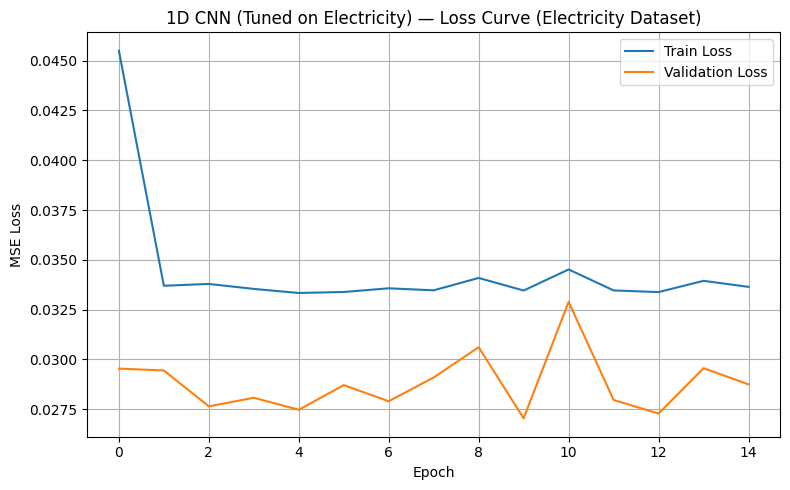

In [112]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_cnn_el, label='Train Loss')
plt.plot(val_losses_cnn_el, label='Validation Loss')
plt.title('1D CNN (Tuned on Electricity) — Loss Curve (Electricity Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


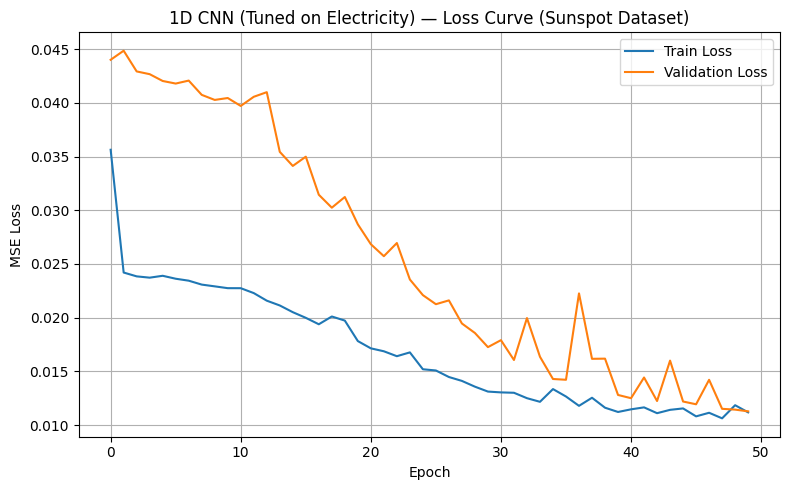

In [113]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_cnn_ss, label='Train Loss')
plt.plot(val_losses_cnn_ss, label='Validation Loss')
plt.title('1D CNN (Tuned on Electricity) — Loss Curve (Sunspot Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


LSTM + CNN

In [ ]:
import optuna
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error

def objective_cnn_lstm_el(trial):
    cnn_filters = trial.suggest_int("cnn_filters", 16, 128)
    kernel_size = trial.suggest_int("kernel_size", 2, 10)
    lstm_hidden = trial.suggest_int("lstm_hidden", 16, 128)
    lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = CNN_LSTM(
        input_size=1,
        cnn_filters=cnn_filters,
        kernel_size=kernel_size,
        lstm_hidden=lstm_hidden,
        lstm_layers=lstm_layers,
        output_size=1
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Light training
    model.train()
    for epoch in range(10):
        for x_batch, y_batch in train_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    val_preds, val_targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch).cpu().numpy()
            val_preds.extend(output.flatten())
            val_targets.extend(y_batch.cpu().numpy().flatten())

    return mean_squared_error(val_targets, val_preds)


In [115]:
study_cnn_lstm_el = optuna.create_study(direction="minimize")
study_cnn_lstm_el.optimize(objective_cnn_lstm_el, n_trials=20)

# Print the best parameters
print("✅ Best CNN + LSTM parameters tuned on Electricity:")
print(study_cnn_lstm_el.best_params)


[I 2025-04-23 21:23:21,541] A new study created in memory with name: no-name-c3104cd9-50bf-486c-8bb5-5847c808494c
[I 2025-04-23 21:23:26,367] Trial 0 finished with value: 0.01385532936534566 and parameters: {'cnn_filters': 128, 'kernel_size': 10, 'lstm_hidden': 45, 'lstm_layers': 3, 'lr': 0.0009876189190641156}. Best is trial 0 with value: 0.01385532936534566.
[I 2025-04-23 21:23:29,495] Trial 1 finished with value: 0.014147257262314016 and parameters: {'cnn_filters': 42, 'kernel_size': 5, 'lstm_hidden': 26, 'lstm_layers': 1, 'lr': 0.00566381954814954}. Best is trial 0 with value: 0.01385532936534566.
[I 2025-04-23 21:23:31,887] Trial 2 finished with value: 0.013245778609376962 and parameters: {'cnn_filters': 111, 'kernel_size': 9, 'lstm_hidden': 30, 'lstm_layers': 2, 'lr': 0.000991598636533496}. Best is trial 2 with value: 0.013245778609376962.
[I 2025-04-23 21:23:33,955] Trial 3 finished with value: 0.016318900865130864 and parameters: {'cnn_filters': 55, 'kernel_size': 7, 'lstm_hidd

✅ Best CNN + LSTM parameters tuned on Electricity:
{'cnn_filters': 55, 'kernel_size': 4, 'lstm_hidden': 69, 'lstm_layers': 3, 'lr': 0.005123179761821285}


In [116]:
import time

model_cnn_lstm_el = CNN_LSTM(
    input_size=1,
    cnn_filters=55,
    kernel_size=4,
    lstm_hidden=69,
    lstm_layers=3,
    output_size=1
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_cnn_lstm_el.parameters(), lr=0.005123179761821285)

train_losses_cnn_lstm_el = []
val_losses_cnn_lstm_el = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    model_cnn_lstm_el.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_cnn_lstm_el(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_el)
    train_losses_cnn_lstm_el.append(train_loss)

    model_cnn_lstm_el.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_el:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_cnn_lstm_el(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_el)
    val_losses_cnn_lstm_el.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_cnn_lstm_el.state_dict(), "cnn_lstm_model_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            model_cnn_lstm_el.load_state_dict(torch.load("cnn_lstm_model_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0272, Val Loss: 0.0145
Epoch 2/50 — Train Loss: 0.0151, Val Loss: 0.0141
Epoch 3/50 — Train Loss: 0.0146, Val Loss: 0.0149
Epoch 4/50 — Train Loss: 0.0149, Val Loss: 0.0187
Epoch 5/50 — Train Loss: 0.0147, Val Loss: 0.0132
Epoch 6/50 — Train Loss: 0.0151, Val Loss: 0.0133
Epoch 7/50 — Train Loss: 0.0139, Val Loss: 0.0133
Epoch 8/50 — Train Loss: 0.0135, Val Loss: 0.0137
Epoch 9/50 — Train Loss: 0.0141, Val Loss: 0.0129
Epoch 10/50 — Train Loss: 0.0135, Val Loss: 0.0142
Epoch 11/50 — Train Loss: 0.0135, Val Loss: 0.0129
Epoch 12/50 — Train Loss: 0.0130, Val Loss: 0.0126
Epoch 13/50 — Train Loss: 0.0133, Val Loss: 0.0127
Epoch 14/50 — Train Loss: 0.0128, Val Loss: 0.0137
Epoch 15/50 — Train Loss: 0.0125, Val Loss: 0.0126
Epoch 16/50 — Train Loss: 0.0124, Val Loss: 0.0130
Epoch 17/50 — Train Loss: 0.0123, Val Loss: 0.0131
Early stopping triggered.
Total training time: 7.93 seconds


In [126]:
model_cnn_lstm_ss = CNN_LSTM(
    input_size=1,
    cnn_filters=55,
    kernel_size=4,
    lstm_hidden=69,
    lstm_layers=3,
    output_size=1
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_cnn_lstm_ss.parameters(), lr=0.005123179761821285)

train_losses_cnn_lstm_ss = []
val_losses_cnn_lstm_ss = []
best_val_loss = float('inf')
epochs_no_improve = 0
patience = 5
start_time = time.time()

for epoch in range(50):
    model_cnn_lstm_ss.train()
    train_loss = 0.0
    for x_batch, y_batch in train_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model_cnn_lstm_ss(x_batch)
        loss = criterion(output, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_ss)
    train_losses_cnn_lstm_ss.append(train_loss)

    model_cnn_lstm_ss.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader_ss:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model_cnn_lstm_ss(x_batch)
            loss = criterion(output, y_batch.squeeze(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader_ss)
    val_losses_cnn_lstm_ss.append(val_loss)

    print(f"Epoch {epoch+1}/50 — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_cnn_lstm_ss.state_dict(), "cnn_lstm_model_ss_from_el_optuna.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print("Early stopping triggered.")
            model_cnn_lstm_ss.load_state_dict(torch.load("cnn_lstm_model_ss_from_el_optuna.pth"))
            break

end_time = time.time()
print(f"Total training time: {end_time - start_time:.2f} seconds")


Epoch 1/50 — Train Loss: 0.0119, Val Loss: 0.0058
Epoch 2/50 — Train Loss: 0.0050, Val Loss: 0.0054
Epoch 3/50 — Train Loss: 0.0050, Val Loss: 0.0089
Epoch 4/50 — Train Loss: 0.0047, Val Loss: 0.0045
Epoch 5/50 — Train Loss: 0.0045, Val Loss: 0.0049
Epoch 6/50 — Train Loss: 0.0045, Val Loss: 0.0045
Epoch 7/50 — Train Loss: 0.0047, Val Loss: 0.0047
Epoch 8/50 — Train Loss: 0.0044, Val Loss: 0.0047
Epoch 9/50 — Train Loss: 0.0045, Val Loss: 0.0059
Epoch 10/50 — Train Loss: 0.0044, Val Loss: 0.0063
Epoch 11/50 — Train Loss: 0.0044, Val Loss: 0.0044
Epoch 12/50 — Train Loss: 0.0045, Val Loss: 0.0044
Epoch 13/50 — Train Loss: 0.0043, Val Loss: 0.0069
Epoch 14/50 — Train Loss: 0.0044, Val Loss: 0.0051
Epoch 15/50 — Train Loss: 0.0044, Val Loss: 0.0041
Epoch 16/50 — Train Loss: 0.0043, Val Loss: 0.0055
Epoch 17/50 — Train Loss: 0.0043, Val Loss: 0.0044
Epoch 18/50 — Train Loss: 0.0044, Val Loss: 0.0052
Epoch 19/50 — Train Loss: 0.0043, Val Loss: 0.0066
Epoch 20/50 — Train Loss: 0.0042, Val Lo

In [127]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_cnn_lstm_el.eval()
preds_el = []
targets_el = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_el:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_cnn_lstm_el(x_batch)
        preds_el.extend(output.cpu().numpy().flatten())
        targets_el.extend(y_batch.cpu().numpy().flatten())

mae_el = mean_absolute_error(targets_el, preds_el)
mse_el = mean_squared_error(targets_el, preds_el)
r2_el = r2_score(targets_el, preds_el)

print("📊 CNN + LSTM (Tuned on Electricity) — Electricity Test Set:")
print(f"MAE: {mae_el:.4f}")
print(f"MSE: {mse_el:.4f}")
print(f"R²: {r2_el:.4f}")


📊 CNN + LSTM (Tuned on Electricity) — Electricity Test Set:
MAE: 0.0662
MSE: 0.0083
R²: 0.3817


In [128]:
model_cnn_lstm_ss.eval()
preds_ss = []
targets_ss = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_ss:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model_cnn_lstm_ss(x_batch)
        preds_ss.extend(output.cpu().numpy().flatten())
        targets_ss.extend(y_batch.cpu().numpy().flatten())

mae_ss = mean_absolute_error(targets_ss, preds_ss)
mse_ss = mean_squared_error(targets_ss, preds_ss)
r2_ss = r2_score(targets_ss, preds_ss)

print("📊 CNN + LSTM (Tuned on Electricity) — Sunspot Test Set:")
print(f"MAE: {mae_ss:.4f}")
print(f"MSE: {mse_ss:.4f}")
print(f"R²: {r2_ss:.4f}")


📊 CNN + LSTM (Tuned on Electricity) — Sunspot Test Set:
MAE: 0.0363
MSE: 0.0024
R²: 0.8809


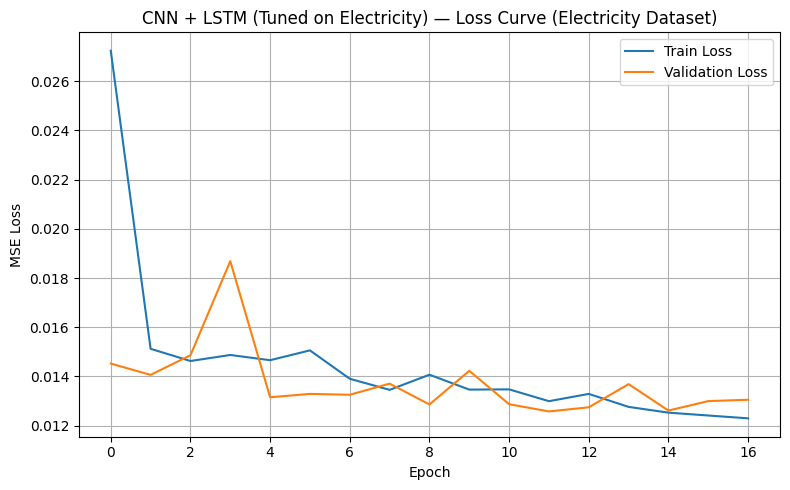

In [129]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_cnn_lstm_el, label='Train Loss')
plt.plot(val_losses_cnn_lstm_el, label='Validation Loss')
plt.title('CNN + LSTM (Tuned on Electricity) — Loss Curve (Electricity Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


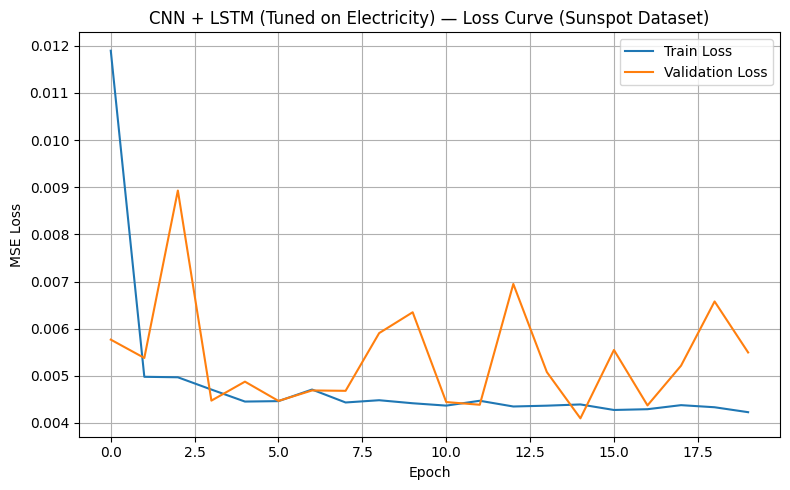

In [130]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_cnn_lstm_ss, label='Train Loss')
plt.plot(val_losses_cnn_lstm_ss, label='Validation Loss')
plt.title('CNN + LSTM (Tuned on Electricity) — Loss Curve (Sunspot Dataset)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
